# Forcing — Time-Varying Inputs

`pb.core.Forcing` is the unified interface for all time-varying inputs in PaleoBeasts. A `Forcing` object is **strictly a function of time** — it maps any scalar time value `t` to a scalar (or array) output via `.get_forcing(t)`, with no dependence on model state.

It wraps four construction patterns — callable, array, composable elements, and bundled datasets — behind a common interface. Forcings are attached to models **after construction** via `register_forcing`; see that section for the full set of options.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import paleobeasts as pb

## Construction patterns

### 1. Callable

Any function of time `t`. No pre-processing, no interpolation overhead.
The simplest way to express analytical signals.

In [40]:
# Any Python callable works — constant, polynomial, sinusoidal, etc.
f_const  = pb.core.Forcing(lambda t: 1.0)
f_linear = pb.core.Forcing(lambda t: 0.01 * t)
f_sin    = pb.core.Forcing(lambda t: np.sin(2 * np.pi * t / 10.0))

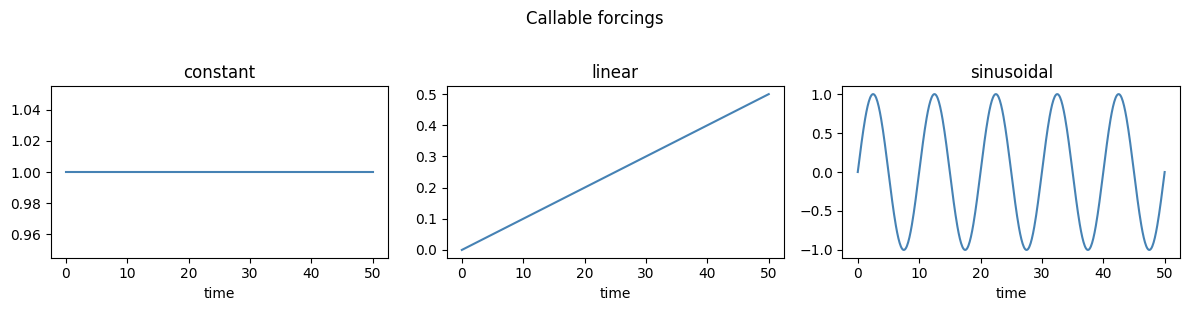

In [41]:
t_plot = np.linspace(0, 50, 500)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, f, label in zip(axes,
                        [f_const, f_linear, f_sin],
                        ["constant", "linear", "sinusoidal"]):
    ax.plot(t_plot, [f.get_forcing(t) for t in t_plot], color="steelblue")
    ax.set_title(label); ax.set_xlabel("time")
plt.suptitle("Callable forcings", y=1.02)
plt.tight_layout(); plt.show()

### 2. Array + time axis

Interpolated from a data array and a matching time axis. Default interpolation is cubic spline; pass `interpolation="linear"` for piecewise linear. Useful for wrapping proxy records, reanalysis output, or any pre-computed time series.

In [42]:
# Sparse data record (e.g. a proxy reconstruction at irregular time points)
t_data = np.array([  0., 10., 20., 30., 40., 50.])
v_data = np.array([  0.,  1.,  0.5, 2.,  1.,  0.])

f_cubic  = pb.core.Forcing(data=v_data, time=t_data)                         # cubic spline (default)
f_linear = pb.core.Forcing(data=v_data, time=t_data, interpolation="linear") # piecewise linear

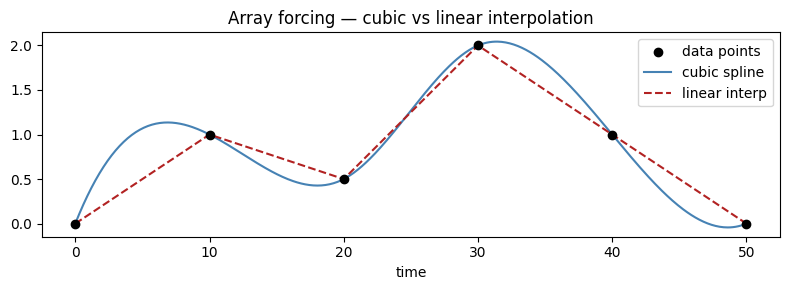

In [43]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(t_data, v_data, color="k", zorder=3, label="data points")
ax.plot(t_plot, [f_cubic.get_forcing(t) for t in t_plot],
        color="steelblue", label="cubic spline")
ax.plot(t_plot, [f_linear.get_forcing(t) for t in t_plot],
        color="firebrick", ls="--", label="linear interp")
ax.set_xlabel("time"); ax.legend()
ax.set_title("Array forcing — cubic vs linear interpolation")
plt.tight_layout(); plt.show()

### 3. `from_sequence` — composable elements

Three element types chain end-to-end in time. Each element's start value is inferred from the previous element's end value when not specified explicitly.

The elements are: **`Ramp`** (monotonic transition), **`Harmonic`** (sinusoidal), and **`Hold`** (constant connector between other elements).

#### Components
##### `Ramp` — monotonic transition

`Ramp(duration, y0, yf, shape)` transitions between two values over `duration` time units. `shape` is `"linear"` (default) or `"cosine"` (smooth S-curve, no discontinuous derivative at the endpoints).

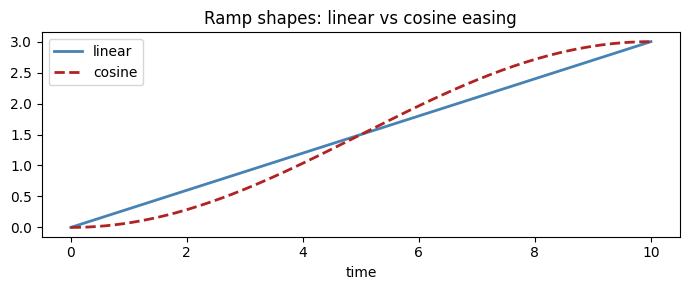

In [44]:
r_linear = pb.core.Ramp(duration=10, y0=0.0, yf=3.0, shape="linear")
r_cosine = pb.core.Ramp(duration=10, y0=0.0, yf=3.0, shape="cosine")

t_ramp = np.linspace(0, 10, 200)
f_rl = pb.core.Forcing.from_sequence([r_linear])
f_rc = pb.core.Forcing.from_sequence([r_cosine])

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t_ramp, [f_rl.get_forcing(t) for t in t_ramp],
        label="linear",  color="steelblue", lw=2)
ax.plot(t_ramp, [f_rc.get_forcing(t) for t in t_ramp],
        label="cosine",  color="firebrick", ls="--", lw=2)
ax.set_xlabel("time"); ax.set_title("Ramp shapes: linear vs cosine easing")
ax.legend(); plt.tight_layout(); plt.show()

##### `Harmonic` — sinusoidal segment

`Harmonic(duration, period, A, center)` generates a sinusoidal signal for `duration` time units. The phase is set automatically so the segment starts at the value inherited from the previous element (or at `center` if it is the first).

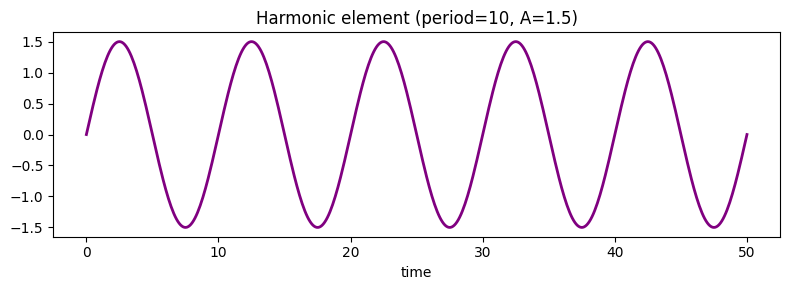

In [45]:
harm = pb.core.Harmonic(duration=50, period=10, A=1.5, center=0.0)
f_harm = pb.core.Forcing.from_sequence([harm])

t_harm = np.linspace(0, 50, 500)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_harm, [f_harm.get_forcing(t) for t in t_harm], color="purple", lw=2)
ax.set_xlabel("time"); ax.set_title("Harmonic element (period=10, A=1.5)")
plt.tight_layout(); plt.show()

##### `Hold` — constant segment

`Hold(duration, value)` holds a constant value for `duration` time units. Most useful as a connector — a baseline before a perturbation, or a plateau after a ramp.

#### Building a sequence

`from_sequence` accepts a list of elements. Here a solar dimming-recovery scenario:
two holds and two ramps (one linear, one cosine for variety), surrounding a period of reduced solar output. Each piece is shown individually first, then the full signal with segments colored by element type.

In [46]:
# Define each piece
piece1 = pb.core.Hold(duration=100, value=1365.0)                              # baseline hold
piece2 = pb.core.Ramp(duration=50,  y0=1365.0, yf=1300.0, shape="cosine")     # cosine ramp down
piece3 = pb.core.Hold(duration=100, value=1300.0)                              # hold at reduced S0
piece4 = pb.core.Ramp(duration=50,  y0=1300.0, yf=1365.0, shape="linear")     # linear ramp back up
piece5 = pb.core.Hold(duration=200, value=1365.0)                              # return to baseline

solar_seq = pb.core.Forcing.from_sequence([piece1, piece2, piece3, piece4, piece5])

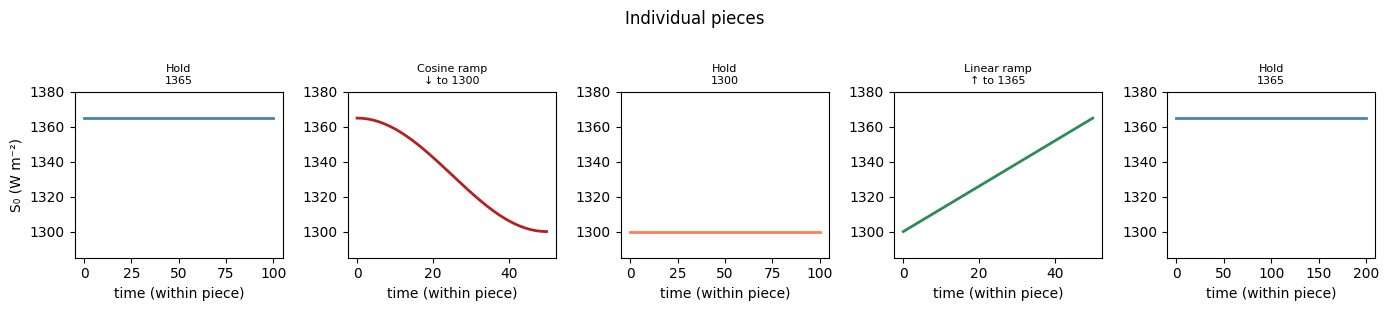

In [47]:
# --- Individual pieces in their own subplots ---
pieces  = [piece1, piece2, piece3, piece4, piece5]
labels  = ["Hold\n1365", "Cosine ramp\n↓ to 1300", "Hold\n1300",
           "Linear ramp\n↑ to 1365", "Hold\n1365"]
colors  = ["steelblue", "firebrick", "coral", "seagreen", "steelblue"]
breaks  = np.cumsum([0, 100, 50, 100, 50, 200])

t_full  = np.linspace(0, 500, 2000)
f_full  = np.array([solar_seq.get_forcing(t) for t in t_full])

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for i, (label, color) in enumerate(zip(labels, colors)):
    t0, t1 = breaks[i], breaks[i + 1]
    f_piece = pb.core.Forcing.from_sequence([pieces[i]])
    t_p = np.linspace(0, t1 - t0, 200)
    axes[i].plot(t_p, [f_piece.get_forcing(t) for t in t_p], color=color, lw=2)
    axes[i].set_title(label, fontsize=8)
    axes[i].set_ylim(1285, 1380)
    axes[i].set_xlabel("time (within piece)")
    if i == 0: axes[i].set_ylabel("S₀ (W m⁻²)")

plt.suptitle("Individual pieces", y=1.02)
plt.tight_layout(); plt.show()

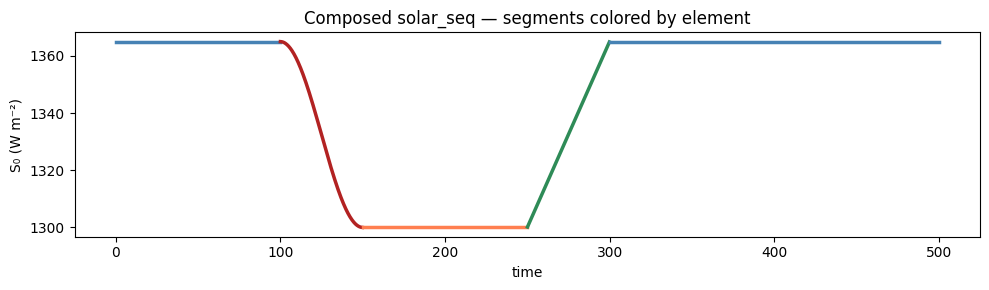

In [48]:
# --- Full sequence with segments colored by element ---
fig, ax = plt.subplots(figsize=(10, 3))
for i, color in enumerate(colors):
    t0, t1 = breaks[i], breaks[i + 1]
    mask = (t_full >= t0) & (t_full <= t1)
    ax.plot(t_full[mask], f_full[mask], color=color, lw=2.5)

ax.set_xlabel("time"); ax.set_ylabel("S₀ (W m⁻²)")
ax.set_title("Composed solar_seq — segments colored by element")
plt.tight_layout(); plt.show()

#### Composing with `+`

Elements can be chained with `+` instead of building a list — returns a `ForcingSequence`
that `Forcing()` accepts directly. Equivalent to `from_sequence`, just more readable
for short sequences.

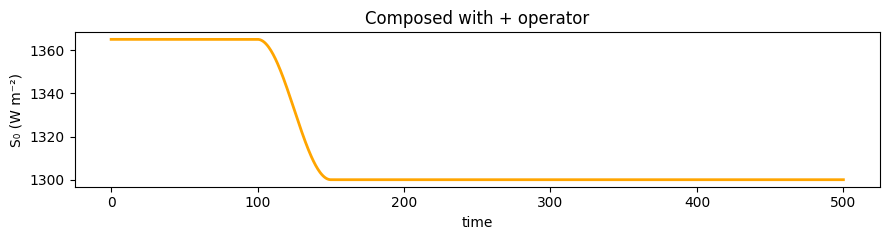

In [49]:
f_composed = pb.core.Forcing(
    pb.core.Hold(duration=100, value=1365.0)
    + pb.core.Ramp(duration=50,  y0=1365.0, yf=1300.0, shape="cosine")
    + pb.core.Hold(duration=350, value=1300.0)
)

# Plot to confirm it evaluates correctly
t_c = np.linspace(0, 500, 1000)
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.plot(t_c, [f_composed.get_forcing(t) for t in t_c], color="orange", lw=2)
ax.set_xlabel("time"); ax.set_ylabel("S₀ (W m⁻²)")
ax.set_title("Composed with + operator")
plt.tight_layout(); plt.show()

### 4. `from_csv` — bundled datasets

Two datasets are bundled with PaleoBeasts:

In [50]:
tsi   = pb.core.Forcing.from_csv(dataset="vieira_tsi")   # Total Solar Irradiance, yr BP
insol = pb.core.Forcing.from_csv(dataset="insolation")   # 65°N insolation anomaly, kyr

print(f"vieira_tsi:  t = {tsi.time.min():.0f} – {tsi.time.max():.0f} yr BP, "
      f"S0 = {tsi.data.min():.2f} – {tsi.data.max():.2f} W m⁻²")
print(f"insolation:  t = {insol.time.min():.0f} – {insol.time.max():.0f} kyr, "
      f"range = {insol.data.min():.1f} – {insol.data.max():.1f}")

vieira_tsi:  t = 0 – 7840 yr BP, S0 = 340.01 – 340.41 W m⁻²
insolation:  t = -5000 – 0 kyr, range = -61.6 – 70.8


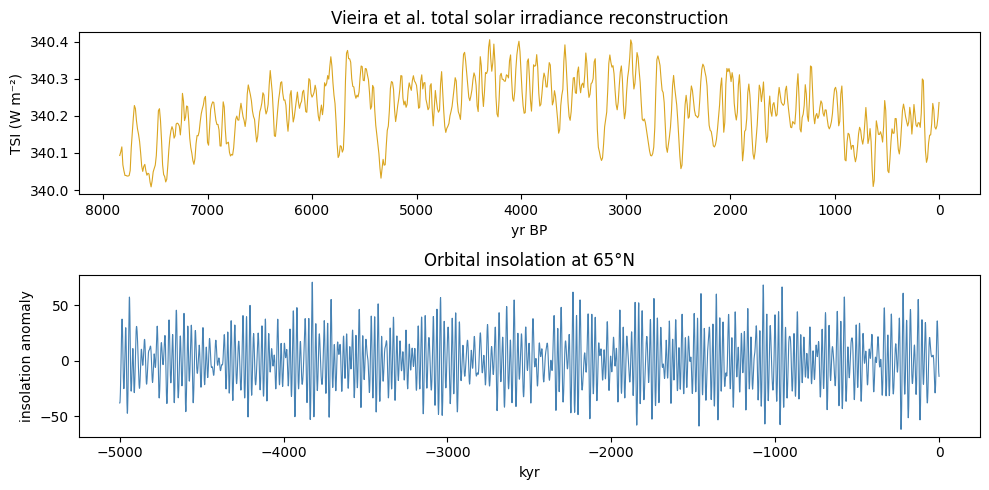

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

axes[0].plot(tsi.time, tsi.data, color="goldenrod", lw=0.8)
axes[0].invert_xaxis()   # BP convention: older on the right
axes[0].set_xlabel("yr BP"); axes[0].set_ylabel("TSI (W m⁻²)")
axes[0].set_title("Vieira et al. total solar irradiance reconstruction")

axes[1].plot(insol.time, insol.data, color="steelblue", lw=0.8)
axes[1].set_xlabel("kyr"); axes[1].set_ylabel("insolation anomaly")
axes[1].set_title("Orbital insolation at 65°N")

plt.tight_layout(); plt.show()

## `register_forcing` — attaching to a model

`register_forcing(var_name, forcing_obj, attachment_style, timing)` wires a `Forcing` object into a model's integration loop. It wraps `dydt` transparently — no changes to the model subclass are needed.

There are two target types (**parameter** or **state variable**) and two dimensions of control (**attachment style** and **timing**):


### Attachment style: `"replacement"` vs `"additive"`

**`"replacement"`** — the forcing value *substitutes* the current parameter or state completely. 
Nothing else is added; the original value is irrelevant during that step.

**`"additive"`** — the forcing value is *injected on top of* whatever the model is already computing. 
For a parameter this is rarely what you want (use a callable instead); for a state variable it acts as an external source or sink term.



### Timing: "pre" vs "post"

**`"pre"`** — applied *inside the right-hand side* at each solver function evaluation.
For a parameter replacement, `param_values` is temporarily patched so `get_param_value` sees the forced value throughout `dydt`. For an additive state variable, the forcing value is added to `dxdt[idx]` — it enters as a rate (same units as `dx/dt`).

**`"post"`** — applied *after each accepted integration step*.
For state replacement, `x[idx]` is set to `forcing(t)` — prescribing the state directly (useful for nudging or data assimilation). For additive state, `forcing(t)` is added to `x[idx]` as a finite jump per step.

> **Adaptive solvers and post-step:** `"post"` timing requires a fixed-step solver (`"euler"`, `"rk4"`, `"euler_maruyama"`). Adaptive solvers (`"RK45"` and other `scipy.integrate.solve_ivp` methods) do not expose a per-step callback, so post-step forcings are silently skipped — `PBModel.integrate()` will emit a warning.



### Valid combinations by target

| Target | Style | Timing | Effect |
|--------|-------|--------|--------|
| Parameter | `replacement` | `pre` (only option) | `param_values[name]` is patched to `forcing(t)` during each `dydt` call |
| State var | `replacement` | `post` (only option) | `x[idx]` is set to `forcing(t)` after each accepted step (fixed-step solvers only) |
| State var | `additive` | `pre` | `forcing(t)` is added to `dxdt[idx]` — a continuous source/sink rate |
| State var | `additive` | `post` | `forcing(t)` is added to `x[idx]` after each step (fixed-step only) |

```python
# Parameter — replacement is the only valid style; timing is always pre
model.register_forcing("S0", my_forcing)

# State variable additive pre — adds to dS/dt at every RHS evaluation (works with RK45)
model.register_forcing("S", fw, "additive", timing="pre")

# State variable replacement post — prescribes S after each step (fixed-step solvers only)
model.register_forcing("S", fw, "replacement", timing="post")
```



### Inspecting and clearing

```python
model.get_forcings()            # dict of all registered forcings
model.get_forcings("S0")        # list of ForcingSpec for one variable
model.clear_forcings()          # remove all forcings
model.clear_forcings("S0")      # remove forcings on one variable only
```

### Noise and stochastic forcing

Noise can enter a model through `register_forcing` or through dedicated SDE solvers:

**Via `register_forcing`** — wrap any stochastic callable in a `Forcing` and attach it as an additive state variable forcing. This is convenient for post-hoc exploration but mixes noise into the deterministic solver, which can affect step-size selection in adaptive solvers.

```python
rng = np.random.default_rng(42)
noise = pb.core.Forcing(lambda t: rng.normal(0, 0.05))   # white noise
model.register_forcing("S", noise, "additive", timing="pre")
```

**Via SDE solvers** — the cleanest approach for stochastic integration.
Define `sde_noise(t, x)` on the model and pass a stochastic method to `integrate()`:

```python
# heun_maruyama: strong order 1 for additive noise
output = model.integrate(t_span=(0, 100), y0=[...], method="heun_maruyama",
                         dt=0.1, random_seed=42)
# milstein: strong order 1 for multiplicative noise (diffusion depends on state)
output = model.integrate(t_span=(0, 100), y0=[...], method="milstein",
                         dt=0.1, random_seed=42)
```

See the noise utilities (`pb.utils.noise`) for post-hoc noise application to already-integrated output.